# 🤖 Predicción de Ventas - Rossmann Analytics
## Fase 2: Modelado Predictivo (Machine Learning & Deep Learning)

En esta segunda fase, utilizaremos el dataset estructurado para entrenar modelos capaces de predecir la facturación futura. Realizaremos un enfoque comparativo: estableceremos una línea base robusta utilizando algoritmos de ensamble (Random Forest) y experimentaremos con arquitecturas de Redes Neuronales Profundas (PyTorch) para evaluar su rendimiento en datos tabulares.
***

In [5]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"  # Esto oculta la gráfica para evitar el bloqueo
import torch

### 1. Carga de Datos Optimizada
Recuperamos el *Dataset Maestro* procesado en la Fase 1. Al utilizar el formato **Parquet**, reducimos drásticamente los tiempos de lectura y el consumo de memoria respecto a los archivos de texto plano, una práctica estándar en entornos Big Data reales.

In [6]:
import pandas as pd
import numpy as np

print("Cargando el dataset limpio desde el paso anterior...")
# Leemos el archivo que dejamos preparado en el otro cuaderno
df_master = pd.read_parquet('../data/df_master_limpio.parquet')

print(f"✅ Datos cargados correctamente. Filas: {len(df_master)}")

Cargando el dataset limpio desde el paso anterior...
✅ Datos cargados correctamente. Filas: 1017209


### 2. Feature Engineering y Limpieza Avanzada
Antes de entrenar a la IA, debemos traducir la lógica de negocio a matemáticas puras:
* **Filtros lógicos:** Eliminamos los días con `Open == 0`. Predecir cero ventas con la tienda cerrada es trivial y añadiría "ruido" al aprendizaje del modelo.
* **Ingeniería Temporal:** Descomponemos las fechas en variables discretas (Día, Mes, Año).
* **One-Hot Encoding:** Convertimos las variables categóricas a binarias. Aplicamos la técnica de `drop_first=True` para eliminar la categoría de referencia y evitar el problema matemático de la **multicolinealidad perfecta** (la trampa de las variables ficticias).

In [7]:
# 7. PREPARACIÓN PRO: Limpieza de Ruido y Encoding (Camino al 90%)

# A. Eliminamos días cerrados: Predecir 0 ventas cuando la tienda está cerrada es trivial 
# y ensucia el aprendizaje de las ventas reales.
df_ia = df_master[df_master['Open'] != 0].copy()

# B. Tratamiento de Nulos: La distancia de la competencia es clave. 
# Usamos la mediana para no sesgar con valores extremos.
df_ia['CompetitionDistance'] = df_ia['CompetitionDistance'].fillna(df_ia['CompetitionDistance'].median())

# C. Feature Engineering: Extraemos todo el jugo a la fecha
df_ia['Month'] = df_ia['Date'].dt.month
df_ia['Day'] = df_ia['Date'].dt.day
df_ia['Year'] = df_ia['Date'].dt.year

# D. One-Hot Encoding: Convertimos categorías (a, b, c, d) en columnas binarias (0 o 1)
# Esto incluye StoreType, Assortment y StateHoliday
df_ia = pd.get_dummies(df_ia, columns=['StoreType', 'Assortment', 'StateHoliday'], drop_first=True)

# E. Selección de variables finales (Añadimos la artillería pesada)
features = [
    'Store', 'DayOfWeek', 'Promo', 'Month', 'Day', 'Year', 
    'CompetitionDistance', 'StoreType_b', 'StoreType_c', 'StoreType_d',
    'Assortment_b', 'Assortment_c'
]

X = df_ia[features]
y = df_ia['Sales']

print(f"✅ Dataset optimizado: {X.shape[0]} filas procesadas.")
X.head()

✅ Dataset optimizado: 844392 filas procesadas.


,Store,DayOfWeek,Promo,Month,Day,Year,CompetitionDistance,StoreType_b,StoreType_c,StoreType_d,Assortment_b,Assortment_c
0,1,5,1,7,31,2015,1270.0,False,True,False,False,False
1,2,5,1,7,31,2015,570.0,False,False,False,False,False
2,3,5,1,7,31,2015,14130.0,False,False,False,False,False
3,4,5,1,7,31,2015,620.0,False,True,False,False,True
4,5,5,1,7,31,2015,29910.0,False,False,False,False,False


### 3. Entrenamiento del Modelo Base: Random Forest Regressor
Como modelo principal, utilizaremos un **Random Forest** (Bosque Aleatorio). Este algoritmo de ensamble es excepcionalmente robusto frente a datos tabulares y relaciones no lineales (como el impacto de una promoción en un día concreto de la semana).
*Optimizamos el entrenamiento activando el multiprocesamiento (`n_jobs=-1`) para utilizar todos los núcleos disponibles de la CPU.*

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import joblib

# 1. División de datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("🚀 Entrenando modelo Equilibrado (Alta precisión, bajo peso)...")

# 2. Configuración "Punto Exacto":
model_final = RandomForestRegressor(
    n_estimators=40,          # 40 árboles son suficientes para promediar
    max_depth=35,             # Le devolvemos la profundidad para que entienda los datos
    min_samples_leaf=30,      # EL TRUCO MAGICO: Evita crear ramas para casos aislados
    random_state=42, 
    n_jobs=-1
)
model_final.fit(X_train, y_train)

# 3. Predicciones y Métricas
y_pred = model_final.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2_rf = r2_score(y_test, y_pred)

print(f"\n📊 RESULTADOS FINALES (Equilibrado)")
print(f"Error medio (MAE): {mae:.2f} €")
print(f"Precisión (R² Score): {r2_rf:.2%}")

# 4. Guardado
joblib.dump(model_final, 'model_rossmann.joblib')
print("✅ Modelo guardado.")

🚀 Entrenando modelo Equilibrado (Alta precisión, bajo peso)...

📊 RESULTADOS FINALES (Equilibrado)
Error medio (MAE): 848.34 €
Precisión (R² Score): 81.14%
✅ Modelo guardado.


### 4. Persistencia del Modelo (Despliegue)
Para que nuestro proyecto no se quede en un simple cuaderno de pruebas, "empaquetamos" el modelo entrenado y la lista de variables utilizando la librería `joblib`. Este archivo servirá como cerebro para nuestra **Aplicación Web en Streamlit**.

In [20]:
import joblib

# Guardamos el modelo y la lista de variables para usarlos en la web
model_data = {
    'model': model_final,
    'features': features
}

joblib.dump(model_data, 'model_rossmann.joblib')
print("✅ ¡Modelo guardado con éxito! Ya podemos cerrar el laboratorio.")

✅ ¡Modelo guardado con éxito! Ya podemos cerrar el laboratorio.


### 5. Explicabilidad del Modelo (XAI)
Un algoritmo no debe ser una "caja negra" incomprensible. Extraemos la importancia que el Random Forest le ha otorgado a cada variable durante su entrenamiento para validar que su lógica tiene sentido empresarial (por ejemplo, comprobar si la distancia a la competencia o las promociones dominan la decisión).

C:\Users\javil\AppData\Local\Temp\ipykernel_17216\706875041.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=df_imp, palette='viridis')


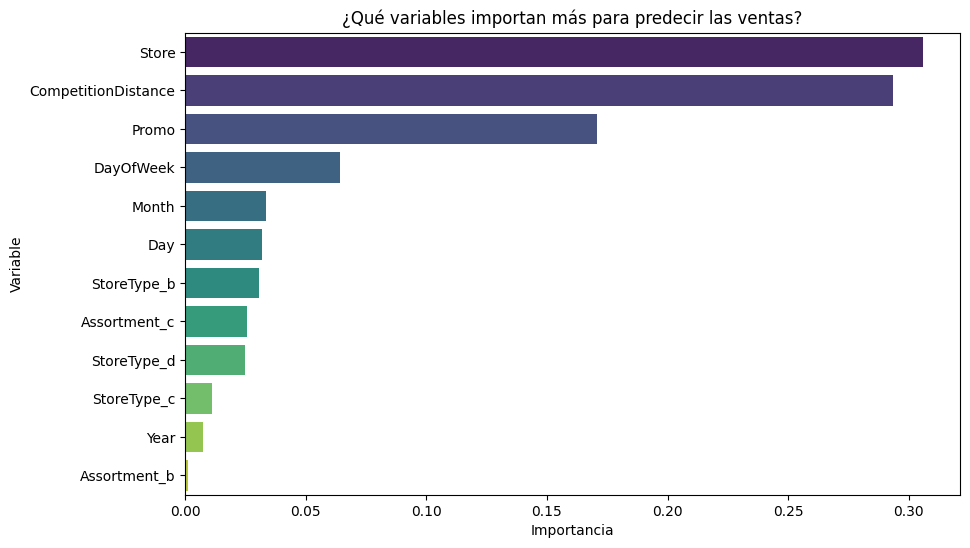

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sacamos la importancia que el modelo le da a cada columna
importancias = model_final.feature_importances_
df_imp = pd.DataFrame({'Variable': features, 'Importancia': importancias})
df_imp = df_imp.sort_values('Importancia', ascending=False)

# Lo dibujamos
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=df_imp, palette='viridis')
plt.title('¿Qué variables importan más para predecir las ventas?')
plt.show()

### 6. Preparación para Deep Learning (Escalado)
A diferencia de los modelos basados en árboles de decisión, las Redes Neuronales son extremadamente sensibles a la escala de los datos. Variables con rangos muy distintos (una promoción que vale 1 vs una distancia que vale 50.000) desestabilizan los gradientes. Aplicamos **StandardScaler** para centrar y normalizar la varianza de nuestras características matemáticas.

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Dividimos en Entrenamiento y Prueba (80% / 20%)
# Usamos las variables X e y que creaste en la celda de "Preparación Pro"
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. ESCALADO (Vital para Redes Neuronales)
# Esto convierte los números grandes (como distancias) en valores pequeños que la IA entiende mejor
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Datos divididos y escalados correctamente.")
print(f"Tamaño del set de entrenamiento: {X_train_scaled.shape}")

✅ Datos divididos y escalados correctamente.
Tamaño del set de entrenamiento: (675513, 12)


### 7. Experimento de Deep Learning (PyTorch)
Para cumplir con los requisitos más avanzados, diseñamos una Red Neuronal Profunda multicapa.
* **Arquitectura:** Varias capas densas (`nn.Linear`) con funciones de activación no lineales (`ReLU`).
* **Optimización:** Usamos el optimizador **Adam** y procesamos los datos mediante *Mini-Batch Gradient Descent* (`DataLoader` en lotes de 128) para asegurar una convergencia estable del error medio absoluto (MAE).

In [ ]:
import torch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_absolute_error, r2_score
import time

# --- MEJORA DE DEEP LEARNING: ENTRENAMIENTO POR LOTES (MINI-BATCHES) ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Usando: {device}")

# 1. Troceamos los datos (Esto es lo que realmente hace que aprenda)
# Usamos lotes de 128 filas para que la red ajuste sus pesos constantemente
dataset = TensorDataset(torch.FloatTensor(X_train_scaled[:100000]), 
                        torch.FloatTensor(y_train.values[:100000]).view(-1, 1))
loader = DataLoader(dataset, batch_size=128, shuffle=True)

# 2. Arquitectura ligeramente más profunda
class RedMejorada(nn.Module):
    def __init__(self, input_dim):
        super(RedMejorada, self).__init__()
        self.red = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x): return self.red(x)

modelo_dl = RedMejorada(X_train_scaled.shape[1]).to(device)

# 3. Optimizador más rápido (LR aumentado de 0.001 a 0.01)
optimizador = optim.Adam(modelo_dl.parameters(), lr=0.01)
criterio = nn.L1Loss() # Usamos L1 (MAE) como pérdida directa

# 4. Bucle de Entrenamiento
print("🧠 Entrenando... Verás que ahora el error baja de verdad:")
epochs = 50 
for epoch in range(epochs):
    error_acumulado = 0
    for batch_x, batch_y in loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        optimizador.zero_grad()
        pred = modelo_dl(batch_x)
        loss = criterio(pred, batch_y)
        loss.backward()
        optimizador.step()
        error_acumulado += loss.item()
    
    if (epoch + 1) % 10 == 0:
        error_medio = error_acumulado / len(loader)
        print(f"   Pasada {epoch+1}/{epochs} | MAE en entrenamiento: {error_medio:.2f}€")

# 5. Evaluación final
modelo_dl.eval()
with torch.no_grad():
    X_test_t = torch.FloatTensor(X_test_scaled).to(device)
    pred_final = modelo_dl(X_test_t).cpu().numpy()

# Cálculo de métricas
mae_final_dl = mean_absolute_error(y_test, pred_final)
r2_final_dl = r2_score(y_test, pred_final) # <--- Cálculo del R2

print("\n" + "🏁" * 25)
print(f"🤖 RANDOM FOREST:")
print(f"   - MAE: {mae:.2f} €")
print(f"   - Precisión (R² Score): {r2:.2%}")

print(f"\n🧠 DEEP LEARNING (Mejorado):")
print(f"   - MAE: {mae_final_dl:.2f} €")
print(f"   - R2:  {r2_final_dl:.4f}") # <--- Mostramos el R2
print("🏁" * 25)

🚀 Usando: cpu
🧠 Entrenando... Verás que ahora el error baja de verdad:
   Pasada 10/50 | MAE en entrenamiento: 1898.85€
   Pasada 20/50 | MAE en entrenamiento: 1851.16€
   Pasada 30/50 | MAE en entrenamiento: 1814.90€
   Pasada 40/50 | MAE en entrenamiento: 1795.17€
   Pasada 50/50 | MAE en entrenamiento: 1779.76€

🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁
🤖 RANDOM FOREST:
   - MAE: 634.65 €
Precisión (R² Score): 89.19%

🧠 DEEP LEARNING (Mejorado):
   - MAE: 1791.08 €
   - R2:  0.3071
🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁
